In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime 


df = pd.read_csv("Filtered_TitleV_Permits.csv")



In [2]:
# Parse dates 
df["Date Received"] = pd.to_datetime(df["Date Received"], errors="coerce")
df["Date Disposed"] = pd.to_datetime(df["Date Disposed"], errors="coerce")
df["Date Expires"] = pd.to_datetime(df["Date Expires"], errors="coerce")

In [3]:
# Compute backlog (18 months rounded to 548 days)
df["processing_days"] = (df["Date Disposed"] - df["Date Received"]).dt.days
df["Disposition Year"] = df["Date Disposed"].dt.year
today = datetime.now()

df["backlogged"] = (
    (df["processing_days"] > 548) | 
    (df["Date Expires"] < today)
)


In [4]:
# Aggregate data by Year AND Region
regional_backlog = (
    df[df["backlogged"]]
    .dropna(subset=["Disposition Year", "Region"])
    .groupby(["Disposition Year", "Region"])
    .size()
    .unstack(fill_value=0) # This turns regions into individual columns for plotting
)

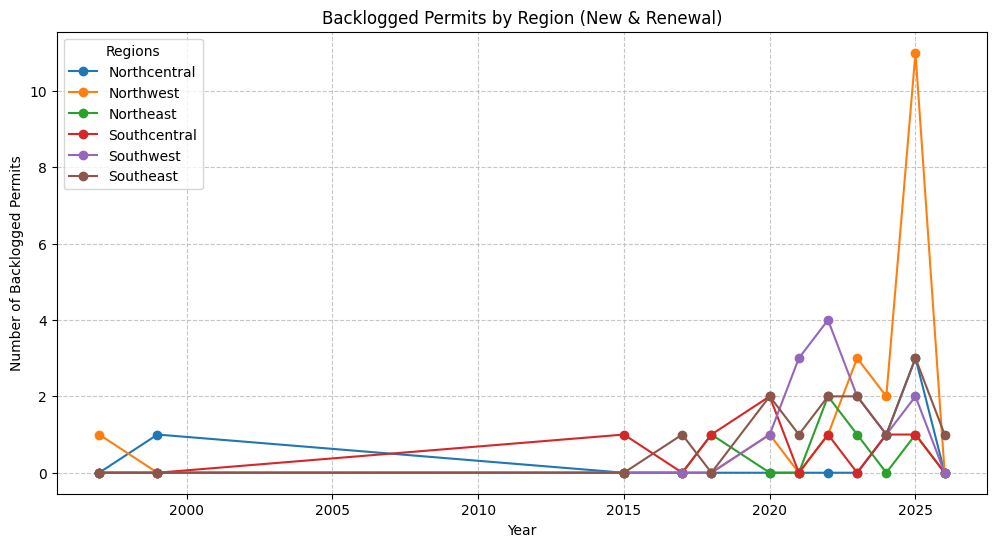

In [5]:
# Classify backlogged permits by Region
regions = ["Northcentral", "Northwest", "Northeast", "Southcentral", "Southwest", "Southeast"]

plt.figure(figsize=(12, 6))
for region in regions:
    if region in regional_backlog.columns:
        plt.plot(regional_backlog.index, regional_backlog[region], marker='o', label=region)

# Visualize line chart 
plt.title("Backlogged Permits by Region (New & Renewal)")
plt.xlabel("Year")
plt.ylabel("Number of Backlogged Permits")
plt.legend(title="Regions")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
# Interacticve graph - Clickable points in order to see the details of the backlogged permits for that year and region
import plotly.express as px

fig = px.line(
    regional_backlog.reset_index(),
    x="Disposition Year",
    y=regions,
    markers=True,
    title="Backlogged Permits by Region (New & Renewal)",
    labels={"Disposition Year": "Year", "value": "Number of Backlogged Permits"},
)
fig.update_layout(legend_title_text="Regions")
fig.show()  
